In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
data = pd.read_csv("iris.csv")

# Features and target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Try different number of trees
tree_values = [10, 20, 50, 100, 200]

best_score = 0
best_trees = 0
best_cm = None

for n in tree_values:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"Trees: {n}, Accuracy: {acc}")

    if acc > best_score:
        best_score = acc
        best_trees = n
        best_cm = confusion_matrix(y_test, y_pred)

# Final Results
print("\nBest Accuracy:", best_score)
print("Best Number of Trees:", best_trees)
print("Confusion Matrix:\n", best_cm)

Trees: 10, Accuracy: 1.0
Trees: 20, Accuracy: 1.0
Trees: 50, Accuracy: 1.0
Trees: 100, Accuracy: 1.0
Trees: 200, Accuracy: 1.0

Best Accuracy: 1.0
Best Number of Trees: 10
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


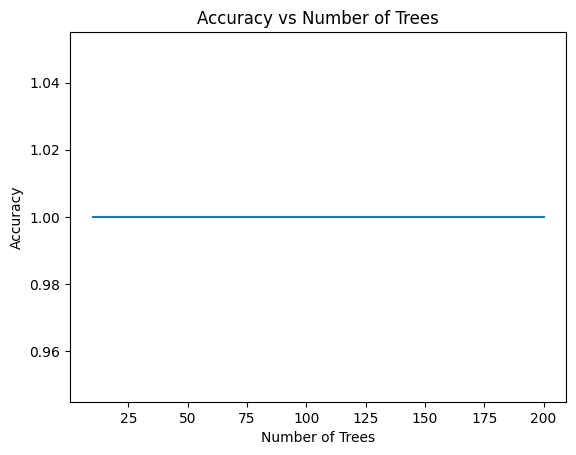

In [4]:
import matplotlib.pyplot as plt

scores = []

for n in tree_values:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

plt.plot(tree_values, scores)
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")
plt.show()